In [3]:
# IMPORTS

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [13]:
# LOAD DATA

path_processed = os.path.join('..', 'data', 'processed')
df = pd.read_csv(os.path.join(path_processed, 'ci_education_15_35.csv'))
df_sector_ci = pd.read_csv('../data/processed/ci_sector_15_35.csv')


In [5]:
# VALIDATION DU PÉRIMÈTRE

print("\n=== CHECK PAYS ===")
print(df['code_pays'].value_counts())

ci_values = ['CIV', "Cote d'Ivoire", "Ivory Coast"]

non_ci = df[~df['code_pays'].isin(ci_values)]

print("\n=== LIGNES NON CI ===")
print(non_ci.shape[0])
print(non_ci['code_pays'].unique())

# STOP logique si erreur (optionnel en pratique)
if non_ci.shape[0] > 0:
    print("\n⚠ WARNING : dataset non strictement filtré Côte d'Ivoire")


=== CHECK PAYS ===
code_pays
CIV    330
Name: count, dtype: int64

=== LIGNES NON CI ===
0
<StringArray>
[]
Length: 0, dtype: str


In [ ]:
# FEATURE IMPORTANTE : VULNÉRABILITÉ

df['vulnerability'] = df['share_unemp'] + df['share_inact']


In [7]:
# SNAPSHOT DERNIÈRE ANNÉE

latest_year = df['annee'].max()
df_now = df[df['annee'] == latest_year]

print("\nAnnée analysée :", latest_year)


Année analysée : 2025


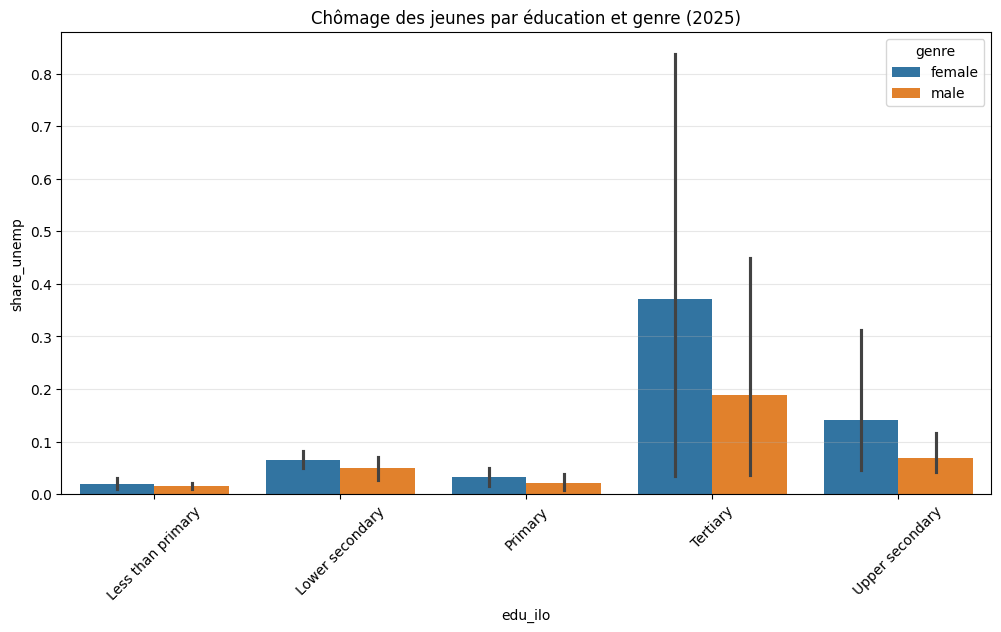

In [8]:
# ANALYSE 1 — CHÔMAGE PAR ÉDUCATION ET GENRE

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_now,
    x='edu_ilo',
    y='share_unemp',
    hue='genre'
)

plt.title(f"Chômage des jeunes par éducation et genre ({latest_year})")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

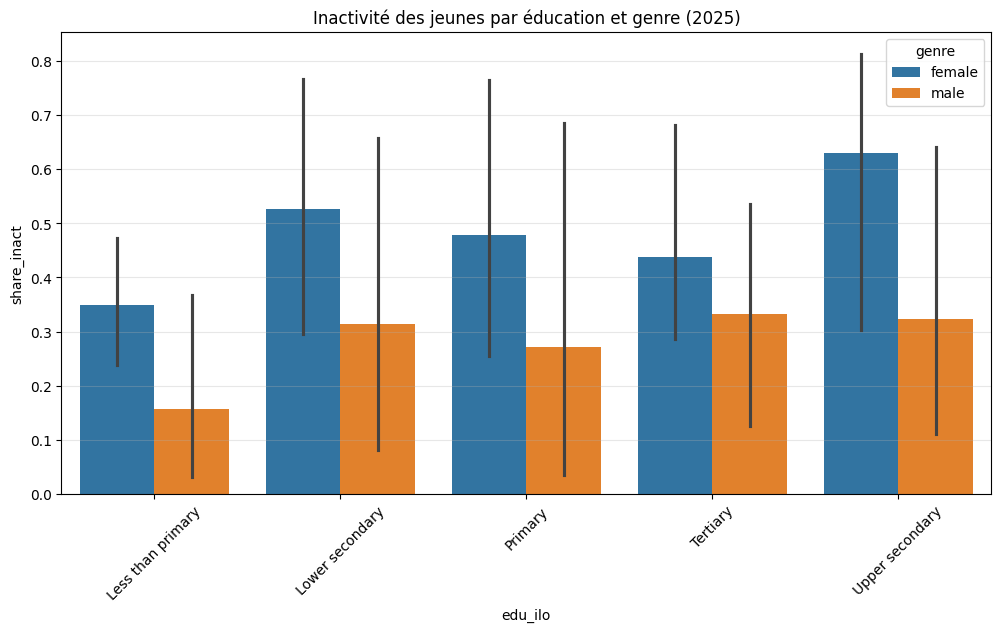

In [ ]:
# ANALYSE 2 — INACTIVITÉ

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_now,
    x='edu_ilo',
    y='share_inact',
    hue='genre'
)

plt.title(f"Inactivité des jeunes par éducation et genre ({latest_year})")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

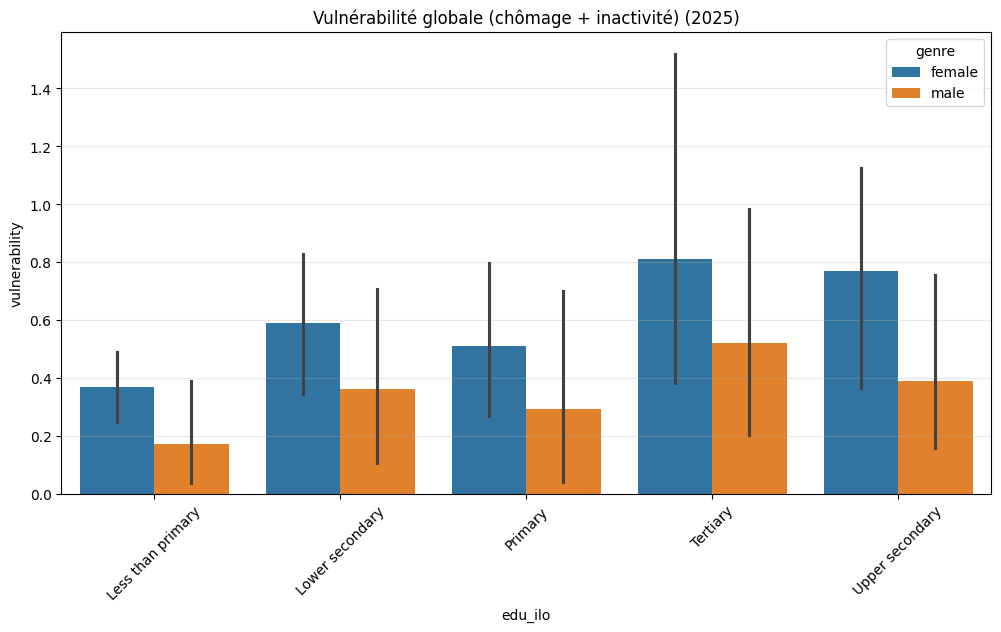

In [ ]:
# ANALYSE 3 — VULNÉRABILITÉ GLOBALE

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_now,
    x='edu_ilo',
    y='vulnerability',
    hue='genre'
)

plt.title(f"Vulnérabilité globale (chômage + inactivité) ({latest_year})")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

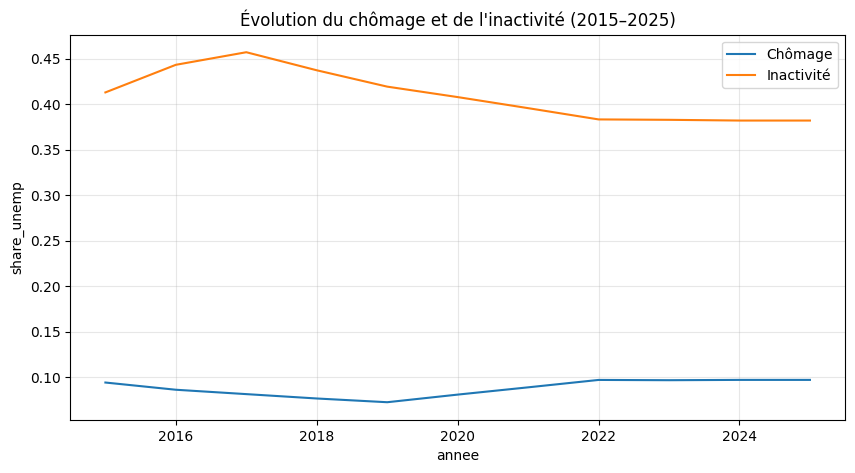

In [11]:
# 9. ANALYSE 4 — TENDANCE TEMPORELLE

df_trend = df.groupby('annee')[['share_unemp', 'share_inact']].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(data=df_trend, x='annee', y='share_unemp', label='Chômage')
sns.lineplot(data=df_trend, x='annee', y='share_inact', label='Inactivité')

plt.title("Évolution du chômage et de l'inactivité (2015–2025)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [12]:
# 10. INSIGHT RAPIDE (NUMÉRIQUE)

print("\n=== INSIGHT GLOBAL ===")
print(df_now.groupby('edu_ilo')[['share_unemp', 'share_inact', 'vulnerability']].mean())


=== INSIGHT GLOBAL ===
                   share_unemp  share_inact  vulnerability
edu_ilo                                                   
Less than primary     0.017802     0.253429       0.271231
Lower secondary       0.057182     0.420798       0.477980
Primary               0.026717     0.374903       0.401620
Tertiary              0.279765     0.385386       0.665151
Upper secondary       0.104669     0.476513       0.581183


/tmp/ipykernel_45945/3464798954.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_dist, x='population', y='sector21', palette='magma')


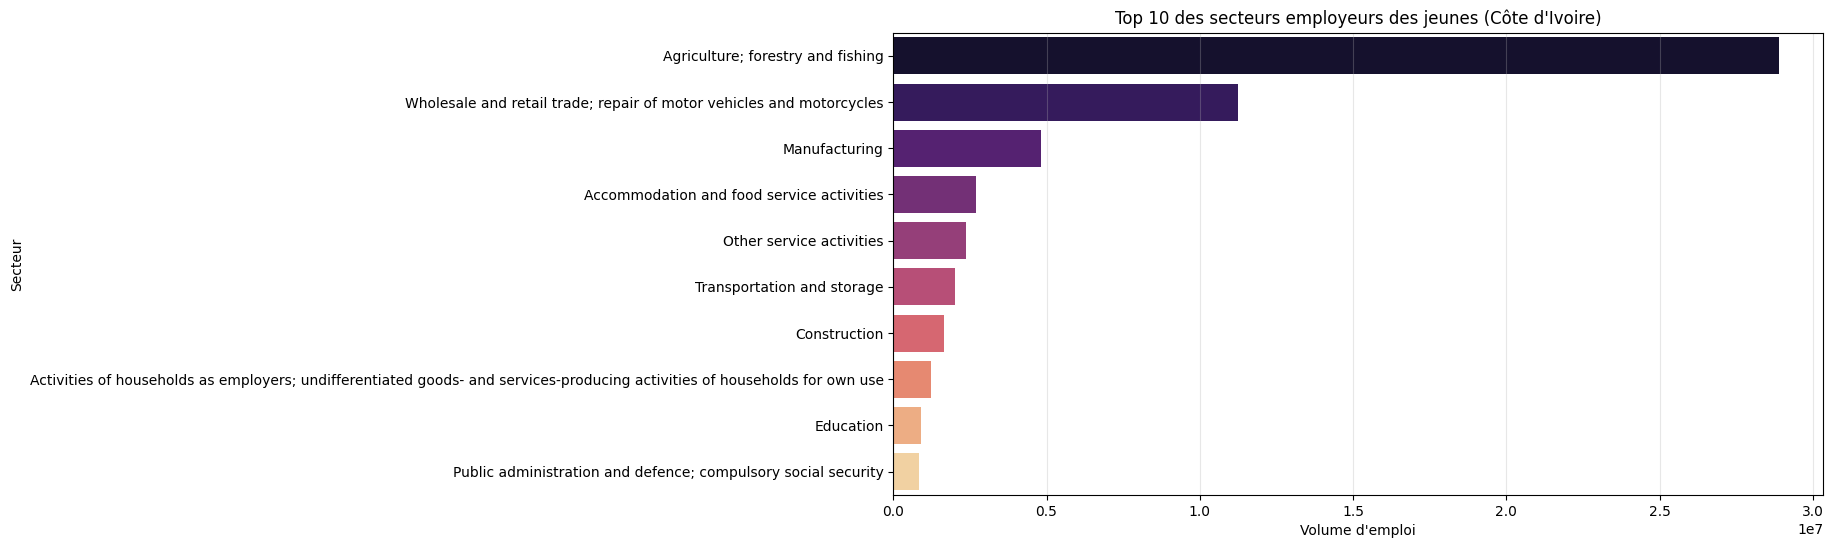

In [16]:
# TOP SECTEURS 

sector_dist = (
    df_sector_ci.groupby('sector21')['population']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=sector_dist, x='population', y='sector21', palette='magma')
plt.title("Top 10 des secteurs employeurs des jeunes (Côte d'Ivoire)")
plt.xlabel("Volume d'emploi")
plt.ylabel("Secteur")
plt.grid(axis='x', alpha=0.3)
plt.show()

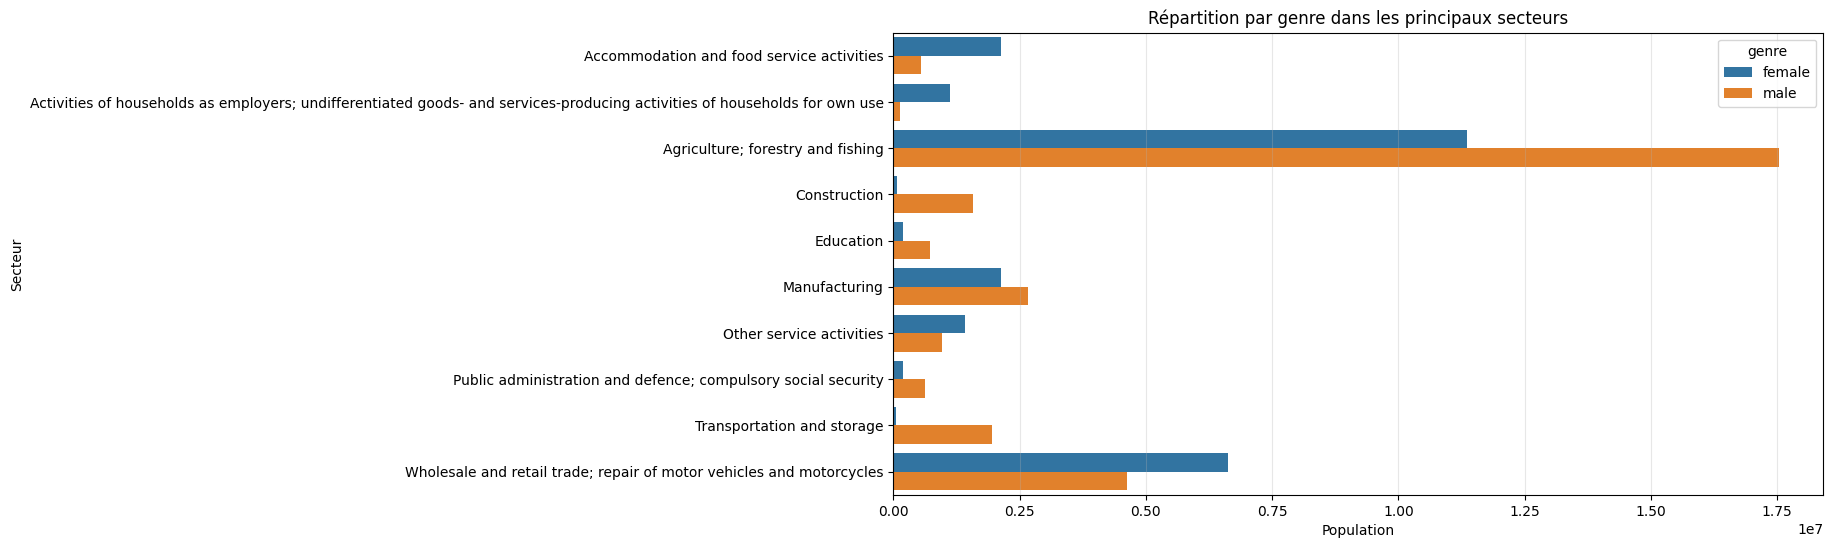

In [ ]:
# GENRE DANS LES SECTEURS CLÉS

top_sectors = sector_dist['sector21'].tolist()
df_top = df_sector_ci[df_sector_ci['sector21'].isin(top_sectors)]

sector_gender = (
    df_top.groupby(['sector21', 'genre'])['population']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=sector_gender, x='population', y='sector21', hue='genre')
plt.title("Répartition par genre dans les principaux secteurs")
plt.xlabel("Population")
plt.ylabel("Secteur")
plt.grid(axis='x', alpha=0.3)
plt.show()

/tmp/ipykernel_45945/2704768698.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_share.head(10), x='share', y='sector21', palette='viridis')


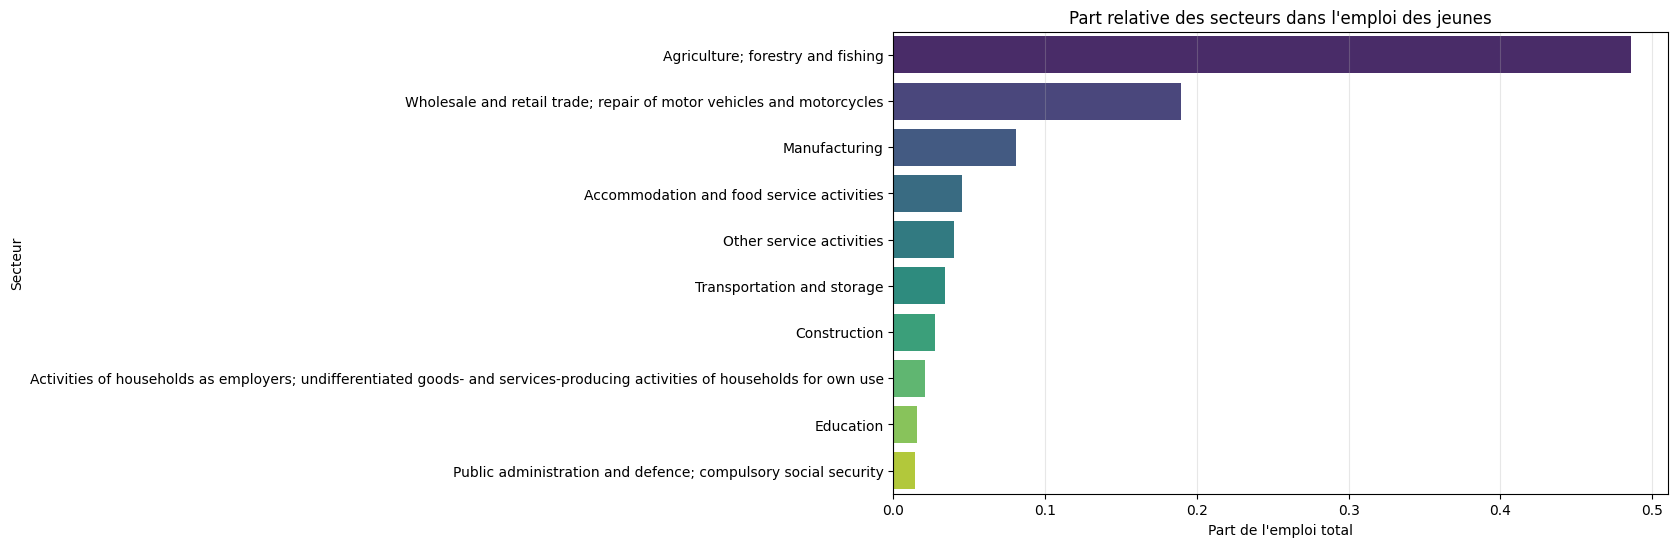

In [20]:
# NOUVELLE ANALYSE CRITIQUE

sector_share = (
    df_sector_ci.groupby('sector21')['population']
    .sum()
    .reset_index()
)

sector_share['share'] = sector_share['population'] / sector_share['population'].sum()

sector_share = sector_share.sort_values('share', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=sector_share.head(10), x='share', y='sector21', palette='viridis')
plt.title("Part relative des secteurs dans l'emploi des jeunes")
plt.xlabel("Part de l'emploi total")
plt.ylabel("Secteur")
plt.grid(axis='x', alpha=0.3)
plt.show()

In [21]:
# INSIGHT STATISTIQUE

print("\n=== CONCENTRATION DE L'EMPLOI ===")
print(sector_share.head(10))

print("\n=== INTERPRÉTATION ===")
print("""
- Si quelques secteurs dominent fortement → économie peu diversifiée
- Si distribution équilibrée → économie plus résiliente
""")


=== CONCENTRATION DE L'EMPLOI ===
                                             sector21  population     share
4                   Agriculture; forestry and fishing  28897468.0  0.486310
20  Wholesale and retail trade; repair of motor ve...  11249038.0  0.189308
12                                      Manufacturing   4804207.0  0.080849
0           Accommodation and food service activities   2692696.0  0.045315
14                           Other service activities   2369389.0  0.039874
18                         Transportation and storage   2016180.0  0.033930
6                                        Construction   1650030.0  0.027768
2   Activities of households as employers; undiffe...   1244720.0  0.020947
7                                           Education    910465.0  0.015322
16  Public administration and defence; compulsory ...    834494.0  0.014044

=== INTERPRÉTATION ===

- Si quelques secteurs dominent fortement → économie peu diversifiée
- Si distribution équilibrée → écon